# BUSINESS PROBLEM - 3
---

## A.BACKGROUND: 

Software development projectstypically follow six basic phases: **requirements**, **design**, **implementation (and integration)**, **testing (validation)**, **deployment (installation)**, and **maintenance**. First, general requirements are gathered, and the scope of the functionality is defined. Then, alternative scenarios for the required functionality are developed and evaluated. Implementation, usually 50% or more of the development time, is the phase in which the design istranslated into programs and integrated with other parts of the software – this is when software engineers actually develop the code. During the final phases, programs are tested, software is put into use, and faults or performance issues are addressed. 

ApDudes, a developer of applications for tablet computers, was having difficulty meeting project deadlines; only 10% of their projects had been completed within budget and on time last year and that was starting to hurt business. The group’s project manager was tasked with studying problems within the implementation phase. He found that software engineers were having difficulty prioritizing their work, and that they often became overwhelmed by the magnitude of the projects.

As a result, two changes were made. Each project was broken down into smaller, distinct tasks, or jobs, and each job was assigned a priority. The project manager believes that this classification and prioritization system would speed the completion of high priority jobs, and thus lower overall project completion time.

## B. BUSINESS PROBLEM: 

We will focus on the prioritization system. If the system is working, then high priority jobs, on average, should be completed more quickly than medium priority jobs, and medium priority jobs should be completed more quickly than low priority jobs. Use the data provided to determine whether this is, in fact, occurring.

## C. DATA AVAILABLE: `Priority_Assessment.csv`

The data set contains a random sample of 642 jobs completed over the lastsix months. The variables in the data set are:

- `Days`: The number of days it took to complete the job
- `Priority`: The priority level assigned to that job
---


In [12]:
import os
import numpy as np
import scipy as sp
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter
from IPython.display import display

In [13]:
# fetching data from source
data_source = "rishikumarrajvansh/hypothesis-testing-case-study"
data = "Priority_Assessment.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  data_source,
  data,
)

In [14]:
display(df.head(10))
display(df.info())

,Days,Priority
0,3.3,High
1,7.9,Medium
2,0.3,High
3,0.7,Medium
4,8.6,Medium
5,0.3,High
6,0.3,High
7,0.3,High
8,72.9,High
9,15.9,Medium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Days      642 non-null    float64
 1   Priority  642 non-null    object 
dtypes: float64(1), object(1)
memory usage: 10.2+ KB


None

### **Problem break-down:**
There are three groups in the dataset. We will perform two tests:

1. Is the mean/median days of high priority group is smaller than medium priority group?
2. Is the mean/median days of medium priority group is smaller than low priority group?

We first visualize and test the normality of the 3 groups.

## 1. Summary Table and Visualization

In [15]:
df.groupby("Priority")["Days"].agg(
    Count="count",
    Q1=lambda x: x.quantile(0.25),
    Median=lambda x: x.quantile(0.5),
    Q3=lambda x: x.quantile(0.75),
    Mean="mean", 
).sort_values("Count")


,Count,Q1,Median,Q3,Mean
Priority,,,,,
Low,67,0.3,1.2,6.150,4.228358
Medium,249,0.2,0.5,2.200,2.500000
High,326,0.2,0.6,2.475,3.023620


<Axes: xlabel='Days', ylabel='Priority'>

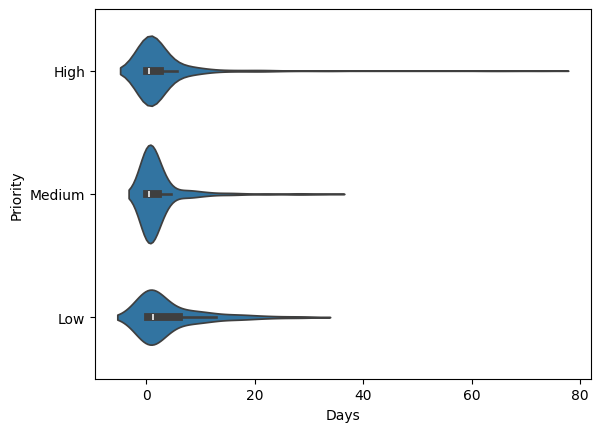

In [16]:
sns.violinplot(data=df, x="Days", y="Priority")

**Comment:** 

- From the visualization and summary table, Group Low has higher distribution than two other groups.
- Group Medium has tendency to have a bit lower distribution than Group High.

## 2. Normality test 

In [17]:
# Shapiro-Wilk test

group_high = df[df["Priority"] == "High"]['Days']
group_medium = df[df["Priority"] == "Medium"]['Days']
group_low = df[df["Priority"] == "Low"]['Days']

stat_high, p_high = sp.stats.shapiro(group_high)
stat_medium, p_medium = sp.stats.shapiro(group_medium)
stat_low, p_low = sp.stats.shapiro(group_low)

print(f"High-priority p-value: {p_high}")
if p_high < 0.05:
    print("Reject H0: Distribution is Not normal")
else:
    print("Fail to reject H0: Distribution is normal")

print(f"Medium-priority p-value: {p_medium}")
if p_medium < 0.05:
    print("Reject H0: Distribution is Not normal")
else:
    print("Fail to reject H0: Distribution is normal")

print(f"Low-priority p-value: {p_low}")
if p_low < 0.05:
    print("Reject H0: Distribution is Not normal")
else:
    print("Fail to reject H0: Distribution is normal")

High-priority p-value: 7.042222819334233e-32
Reject H0: Distribution is Not normal
Medium-priority p-value: 7.518797684243972e-26
Reject H0: Distribution is Not normal
Low-priority p-value: 1.8875302365260902e-10
Reject H0: Distribution is Not normal


Comment: the distributions are not normal and have outliers. We thus choose one-tailed **Mann-Whitney U Test**.

**Null Hypothesis ($H_0$):** The distribution of A is the same as or less than as B.

**Alternative Hypothesis ($H_1$):** The distribution of A is stochastically greater than B.

**Significant level:** $\alpha=0.05$

In [18]:
# Perform Mann-Whitney U test: compares if group_low is greater than group_medium)
U_statistic, p_value = sp.stats.mannwhitneyu(group_low, group_medium, alternative="greater")

# Print the result
print(f'The U-statistic is {U_statistic:.2f} and the p-value is {p_value:}')

if p_value < 0.05:
    print("Reject H0: The days distribution of Group Low is larger than thar of Group Medium")
else:
    print("Fail to reject H0: Group Low is not larger than Group Medium")

The U-statistic is 9960.00 and the p-value is 0.007181971596956215
Reject H0: The days distribution of Group Low is larger than thar of Group Medium


In [19]:
# Perform Mann-Whitney U test: compares if group_medium is greater than group_high
U_statistic, p_value = sp.stats.mannwhitneyu(group_medium, group_high, alternative="greater")

# Print the result
print(f'The U-statistic is {U_statistic:.2f} and the p-value is {p_value:}')


if p_value < 0.05:
    print("Reject H0: The days distribution of Group Medium is larger than thar of Group High")
else:
    print("Fail to reject H0: Group Medium is not larger than Group High")

The U-statistic is 41116.00 and the p-value is 0.393953948888218
Fail to reject H0: Group Medium is not larger than Group High


<div class="alert alert-block alert-success">
<b>Conclusion:</b> The prioritization system is not quite well. In particular, medium priority jobs are more quickly than low priority jobs, but high priority jobs are not proved to be more quickly than medium priority jobs.

</div>